the decision is taken based on the values from the state and it is not defined/hard-coded directly while building the graph.

In [3]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

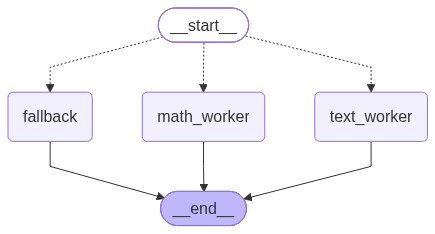

In [19]:
# -- state --
class TaskState(TypedDict):
    task_type: str
    input_data: str
    output: str

def dispatch(state: TaskState) -> Literal["math_worker", "text_worker", "fallback"]:
    task = state["task_type"].lower().strip()
    if task == "math":
        return "math_worker"
    elif task == "text":
        return "text_worker"
    else: return "fallback"

def math_worker(state: TaskState) -> dict:
    try:
        result = str(eval(state["input_data"]))
    except Exception:
        result = "math_error"
    print(f"[math_worker] {state["input_data"]} = {result}")
    return {"output": result}

def text_worker(state: TaskState) -> dict:
    result = state["input_data"].upper()
    print(f"[text_worker] {state["input_data"]}")
    return {"output": result}

def fallback(state: TaskState) -> dict:
    result = f"Unknown task type: '{state["task_type"]}"
    print(f"[fallback] {result}")
    return {"output": result}

builder = StateGraph(TaskState)

builder.add_node("math_worker", math_worker)
builder.add_node("text_worker", text_worker)
builder.add_node("fallback", fallback)

builder.add_conditional_edges(
    START, 
    dispatch,
    {"math_worker": "math_worker",
     "text_worker": "text_worker",
     "fallback": "fallback"}
    )
builder.add_edge("math_worker", END)
builder.add_edge("text_worker", END)
builder.add_edge("fallback", END)

graph = builder.compile()

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


In [20]:
tasks = [
    {"task_type": "math", "input_data": "3 * 7 + 2", "output": ""},
    {"task_type": "text", "input_data": "hello world", "output": ""},
    {"task_type": "unknown", "input_data": "do something", "output": ""},
]

In [23]:
for task in tasks:
    print(f"task type is {task["task_type"]}")
    output = graph.invoke(task)
    print(f"Type: {task["task_type"]}, result: {output["output"]}")

task type is math
[math_worker] 3 * 7 + 2 = 23
Type: math, result: 23
task type is text
[text_worker] hello world
Type: text, result: HELLO WORLD
task type is unknown
[fallback] Unknown task type: 'unknown
Type: unknown, result: Unknown task type: 'unknown
